# EpiAI 教程：跨城市泛化能力评估

> 使用气候特征训练模型，评估模型对**已见城市未来疫情**和
> **从未见过的新城市疫情**的预测效果。

---

## 1. 环境准备

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from EpiAI.models import sklearn_models, ts_models
from EpiAI.models import torch_models

from EpiAI.dataset import (
    ForecastPipeline, CsvLoader, TimeSplit,
    Compose, StandardScaler, DateFeatures,
    SlidingWindow, EntityTimeSplit,
)
from EpiAI.models.registry import get, list_models
from EpiAI.trainer import EpiAITrainer
from EpiAI.inference import ModelVault

np.random.seed(42)

---

## 2. 数据划分

将城市分为两组：
- **已见城市（8 个）**：用于训练和未来预测测试
- **未见城市（2 个）**：完全不在训练集中出现，测试零样本泛化

In [2]:
DF = "../data/China_vector_climate.csv"
df_raw = pd.read_csv(DF)

FEATURES = ["登革热"] + [c for c in df_raw.columns if c.endswith("_mean") and c != "ssrdc_mean"]
TARGET = "登革热"
TIME_COL = "time"

# 按总病例数排序取前 10
prov_ranks = df_raw.groupby("province")["登革热"].sum().sort_values(ascending=False)
top10 = prov_ranks.head(10).index.tolist()

# 分配：8 个已见 + 2 个未见
seen_provinces = top10[:8]      # 广东、云南、福建、广西、浙江、重庆、江西、湖南
unseen_provinces = top10[8:10]  # 四川、海南

df = df_raw[df_raw["province"].isin(top10)].copy()
df = df.rename(columns={"Year/Month": TIME_COL}).reset_index(drop=True)
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

print(f"已见城市 ({len(seen_provinces)}): {seen_provinces}")
print(f"未见城市 ({len(unseen_provinces)}): {unseen_provinces}")
print(f"总样本: {len(df)} ({len(df)//len(top10)} 月 × {len(top10)} 市)")

# 分别保存
df[df["province"].isin(seen_provinces)].to_csv("/tmp/seen.csv", index=False)
df[df["province"].isin(unseen_provinces)].to_csv("/tmp/unseen.csv", index=False)

已见城市 (8): ['广东', '云南', '福建', '广西', '浙江', '重庆', '江西', '湖南']
未见城市 (2): ['四川', '海南']
总样本: 2040 (204 月 × 10 市)


---

## 3. 数据管道（已见城市）
## 3. 数据管道（已见城市）

使用 `EntityTimeSplit` 按城市+时间拆分，确保每个城市各自按时间比例划分训练/验证/测试。

In [3]:
df_seen = pd.read_csv("/tmp/seen.csv")
df_seen["time"] = pd.to_datetime(df_seen[TIME_COL])

# 为每个已见城市计算时间分界点
split_map = {}
for city in seen_provinces:
    city_df = df_seen[df_seen["province"] == city].sort_values("time")
    n = len(city_df)
    train_end = city_df.iloc[int(n * 0.7)]["time"]
    val_end = city_df.iloc[int(n * 0.85)]["time"]
    split_map[city] = (str(train_end.date()), str(val_end.date()))

bundle = ForecastPipeline(
    loader=CsvLoader(time_col=TIME_COL, target_cols=TARGET,
                     feature_cols=FEATURES, entity_col="province"),
    split=EntityTimeSplit(split_map=split_map),
    transforms=Compose([
        StandardScaler(columns=FEATURES),
        DateFeatures(time_col=TIME_COL, features=["month"]),
    ]),
    window=SlidingWindow(lookback=12, horizon=3),
).run("/tmp/seen.csv")

print(f"训练窗口: {bundle.train_x.shape}  ({bundle.n_train} 窗)")
print(f"验证窗口: {bundle.val_x.shape}")
print(f"测试窗口: {bundle.test_x.shape}  ({bundle.n_test} 窗, 来自已见城市的未来时段)")
print(f"特征数: {bundle.n_features}")

训练窗口: (1024, 12, 14)  (1024 窗)
验证窗口: (148, 12, 14)
测试窗口: (148, 12, 14)  (148 窗, 来自已见城市的未来时段)
特征数: 14


---

## 4. 训练模型

In [6]:
results = {}

# ── Sklearn ──
for name in ["RF", "XGB", "SVR", "GLM"]:
    try:
        params = {
            "RF":    {"n_estimators": 200, "max_depth": 10, "random_state": 42},
            "XGB":   {"n_estimators": 200, "random_state": 42},
            # "LGBM":  {"n_estimators": 200, "random_state": 42, "verbose": -1},
            "SVR":   {"kernel": "rbf", "C": 1.0},
            "GLM":   {},
            # "TabPFN": {},
        }
        param_key = {"RF": "rf_params", "XGB": "xgb_params", "LGBM": "lgbm_params",
                     "SVR": "svm_params", "GLM": "glm_params", "TabPFN": "tabpfn_params"}
        model = get(name)(input_dim=bundle.n_features, lookback=12,
                          horizon=3, target_dim=1,
                          **{param_key[name]: params[name]})
        r = EpiAITrainer(model=model, verbose=False).fit(bundle)
        results[name] = r
        m = r.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  r={m['PearsonR']:.3f}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

# ── Torch ──
for name in ["MLP", "LSTM", "CNN", "CNN-LSTM", "ResNet", "TCN",
              "Transformer", "DLinear", "Autoformer", "TimesNet"]:
    try:
        model = get(name)(input_dim=bundle.n_features, lookback=12,
                          horizon=3, target_dim=1)
        r = EpiAITrainer(model=model, verbose=False,
                         optimizer_config={"max_epochs": 20}).fit(bundle)
        results[name] = r
        m = r.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  r={m['PearsonR']:.3f}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

print(f"\n已训练 {len(results)} 个非时序模型")

  ✅ RF          MAE=477  r=0.226
  ✅ XGB         MAE=126  r=0.518
  ✅ SVR         MAE=133  r=0.103
  ❌ GLM: "Unknown model 'GLM'. Available: ['arima', 'autofo
  ✅ MLP         MAE=109  r=0.216
  ✅ LSTM        MAE=147  r=0.059
  ✅ CNN         MAE=123  r=0.279
  ✅ CNN-LSTM    MAE=115  r=0.288
  ✅ ResNet      MAE=385  r=-0.047
  ✅ TCN         MAE=241  r=-0.122
  ✅ Transformer  MAE=156  r=0.364
  ✅ DLinear     MAE=252  r=0.222
  ✅ Autoformer  MAE=400  r=0.131
  ✅ TimesNet    MAE=227  r=-0.060

已训练 13 个非时序模型


---

## 5. 在已见城市的未来测试集上评估

In [8]:
vault = ModelVault.from_results(results, bundle)

print("表 1：已见城市 — 未来时段预测")
print(vault.summary().to_string())

表 1：已见城市 — 未来时段预测
            paradigm         MAE         RMSE          MAPE         R2  PearsonR    n
model                                                                                
XGB          sklearn  126.477821   326.467957  5.924850e+09  -0.012596  0.518413  248
Transformer    torch  155.900101   397.946594  7.810421e+09  -0.504543  0.364037  248
CNN-LSTM       torch  115.055374   322.206238  4.165477e+09   0.013668  0.288198  248
CNN            torch  122.870697   321.038818  5.513826e+09   0.020803  0.278676  248
RF           sklearn  476.622803  1177.084106  2.989489e+10 -12.163457  0.225792  248
DLinear        torch  252.029434   364.502716  2.293167e+10  -0.262282  0.222048  248
MLP            torch  109.098061   324.426758  3.999215e+09   0.000027  0.216381  248
Autoformer     torch  400.130585   555.197876  4.505838e+10  -1.928536  0.130628  248
SVR          sklearn  132.608994   323.836975  8.253232e+09   0.003659  0.103305  248
LSTM           torch  147.471176   3

---

## 6. 在未见城市上评估（零样本泛化）

将训练好的模型直接用于从未见过的城市。核心操作是**对整个城市的时间序列做滑窗预测，
取每个窗口的第一步行预测作为该时间点的预测值**，然后与真实值对比。

In [9]:
def evaluate_on_city(inferer, city_df, lookback, target_col):
    """
    对单个城市的完整时间序列做滑窗预测。

    逻辑
    ----
    inferer.predict(city_df) 内部：
      apply_features_only 创建 N - lookback + 1 个窗口
      但仅 N - lookback 个窗口的第1步预测落在数据范围内。

    返回
    ----
    y_true : ndarray, (M,)    真实值
    y_pred : ndarray, (M,)    预测值
    """
    pred = inferer.predict(city_df)                # (M', horizon, target_dim)
    n_valid = len(city_df) - lookback              # 有效首步预测数
    y_pred = pred[:n_valid, 0, 0]                  # 仅取有效部分
    y_true = city_df[target_col].values[lookback:][:n_valid]
    return y_true, y_pred

from EpiAI import InferencePipeline
from sklearn.metrics import mean_absolute_error

# 加载未见城市数据
df_unseen = pd.read_csv("/tmp/unseen.csv")
df_unseen[TIME_COL] = pd.to_datetime(df_unseen[TIME_COL])

results_unseen = {}
city_results = {}  # {city: {model: {"R2": ..., "MAE": ...}}}

for name in results:
    inferer = InferencePipeline.from_train_result(results[name])
    city_results[name] = {}

    for city in unseen_provinces:
        city_df = df_unseen[df_unseen["province"] == city].reset_index(drop=True)
        if len(city_df) < bundle.lookback + 1:
            continue
        y_true, y_pred = evaluate_on_city(inferer, city_df, bundle.lookback, TARGET)
        city_results[name][city] = {
            "MAE": mean_absolute_error(y_true, y_pred),
        }

    # 汇总（所有城市合并）
    all_true, all_pred = [], []
    for city in city_results[name]:
        y_true, y_pred = evaluate_on_city(inferer,
            df_unseen[df_unseen["province"] == city].reset_index(drop=True),
            bundle.lookback, TARGET)
        all_true.append(y_true)
        all_pred.append(y_pred)
    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    results_unseen[name] = {
        "MAE": mean_absolute_error(all_true, all_pred),
    }

# 打印按城市细分的评估结果
print("\n未见城市零样本评估（按城市 MAE）：")
print(f"{'模型':10s}", end="")
for city in unseen_provinces:
    print(f"  {city:4s} MAE", end="")
print()
for name in results:
    print(f"{name:10s}", end="")
    for city in unseen_provinces:
        v = city_results[name].get(city, {})
        print(f"  {v.get('MAE', float('nan')):>7.0f}", end="")
    print()

print(f"\n{'模型':10s}  {'汇总 MAE':8s}")
for name in results:
    print(f"{name:10s}  {results_unseen[name]['MAE']:>8.0f}")


未见城市零样本评估（按城市 MAE）：
模型          四川   MAE  海南   MAE
RF               14      887
XGB              15       45
SVR              58      122
MLP              19      249
LSTM             21      118
CNN              24      192
CNN-LSTM         43       57
ResNet           77      283
TCN             127      163
Transformer       31      515
DLinear         307      477
Autoformer       78      375
TimesNet         45       75

模型          汇总 MAE  
RF               450
XGB               30
SVR               90
MLP              134
LSTM              70
CNN              108
CNN-LSTM          50
ResNet           180
TCN              145
Transformer       273
DLinear          392
Autoformer       227
TimesNet          60


---

## 7. 可视化

### 7.1 未见城市预测效果（以第一个未见城市为例）

取其中一个未见城市的全部时段，绘制实际值（黑色粗线）和各模型的预测曲线。

/tmp/ipykernel_1915724/2023214005.py:24: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/tmp/generalization_city.png", dpi=150); plt.show()
/tmp/ipykernel_1915724/2023214005.py:24: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/tmp/generalization_city.png", dpi=150); plt.show()
/tmp/ipykernel_1915724/2023214005.py:24: UserWarning: Glyph 30331 (\N{CJK UNIFIED IDEOGRAPH-767B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/tmp/generalization_city.png", dpi=150); plt.show()
/tmp/ipykernel_1915724/2023214005.py:24: UserWarning: Glyph 38761 (\N{CJK UNIFIED IDEOGRAPH-9769}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/tmp/generalization_city.png", dpi=150); plt.show()
/tmp/ipykernel_1915724/2023214005.py:24: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) 

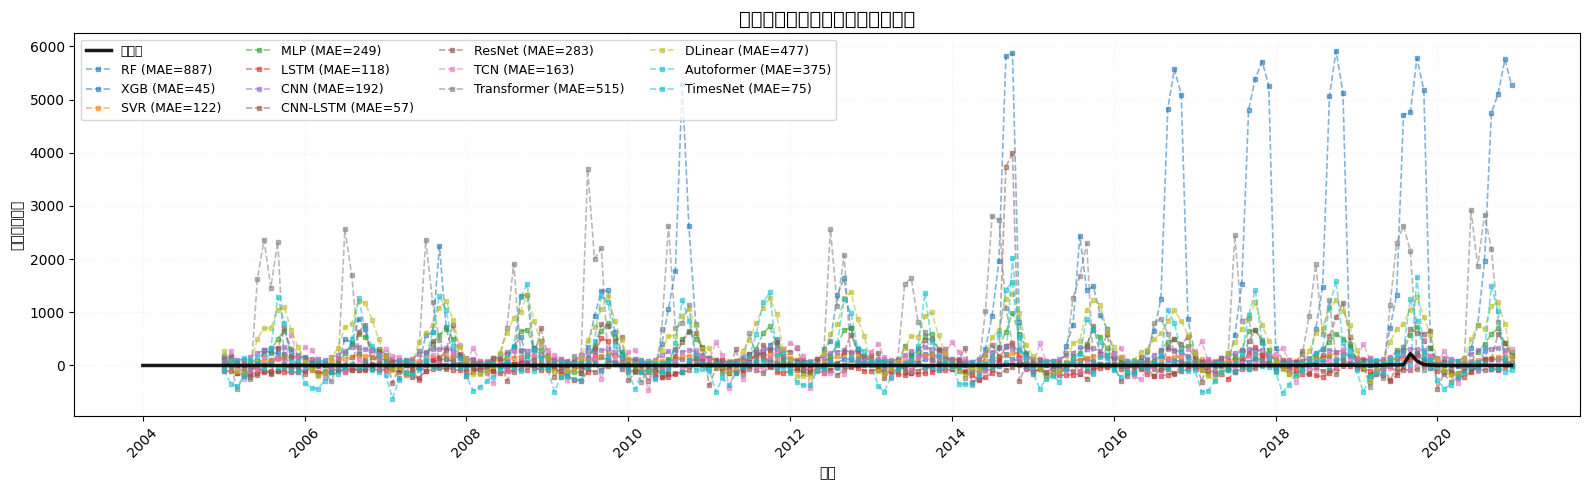

In [11]:
example_city = unseen_provinces[1]
city_df = df_unseen[df_unseen["province"] == example_city].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))

# 实际值（黑色粗线，突出轨迹）
ax.plot(city_df[TIME_COL], city_df[TARGET], "-", color="black",
        linewidth=2.5, alpha=0.9, label="实际值", zorder=5)

# 各模型预测
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for idx, (name, r) in enumerate(results.items()):
    inferer = InferencePipeline.from_train_result(r)
    y_true, y_pred = evaluate_on_city(inferer, city_df, bundle.lookback, TARGET)
    mae = city_results[name].get(example_city, {}).get("MAE", float("nan"))
    pred_time = city_df[TIME_COL].values[bundle.lookback:][:len(y_pred)]
    ax.plot(pred_time, y_pred, "s--", label=f"{name} (MAE={mae:.0f})",
            color=colors[idx], alpha=0.55, markersize=3, linewidth=1.2)

ax.set_title(f"未见城市「{example_city}」零样本预测效果", fontsize=14, fontweight="bold")
ax.set_ylabel("登革热病例数"); ax.set_xlabel("时间"); ax.grid(alpha=0.15, linestyle=":")
ax.legend(fontsize=9, ncol=4, loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig("/tmp/generalization_city.png", dpi=150); plt.show()

### 7.2 泛化能力对比柱状图（MAE）

/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 36328 (\N{CJK UNIFIED IDEOGRAPH-8DE8}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 27867 (\N{CJK UNIFIED IDEOGRAPH-6CDB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from 

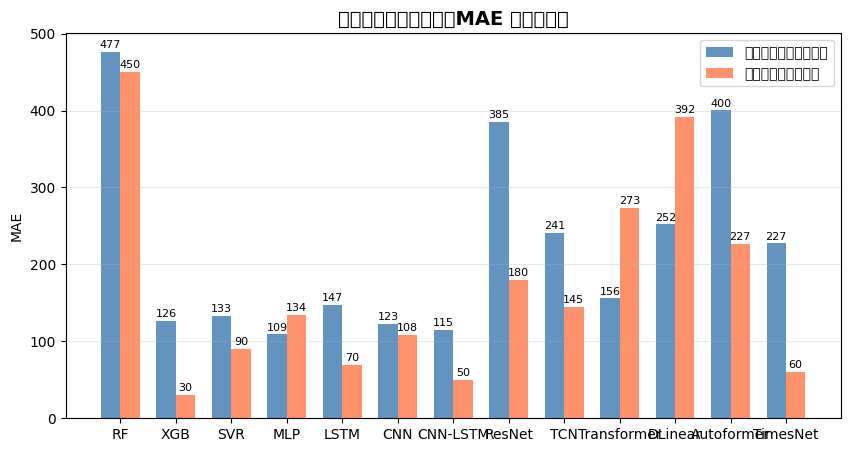

In [12]:
seen_names = [n for n in results]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(seen_names))
width = 0.35

seen_maes = [results[n].metrics.iloc[0]["MAE"] for n in seen_names]
unseen_maes = [results_unseen.get(n, {}).get("MAE", 0) for n in seen_names]

bars1 = ax.bar(x - width/2, seen_maes, width, label="已见城市（未来时段）",
               color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, unseen_maes, width, label="未见城市（零样本）",
               color="coral", alpha=0.85)

ax.set_ylabel("MAE"); ax.set_title("跨城市泛化能力对比（MAE 越低越好）",
              fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(seen_names)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{bar.get_height():.0f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{bar.get_height():.0f}", ha="center", fontsize=8)

# plt.tight_layout(); plt.savefig("/tmp/generalization_bar.png", dpi=150); plt.show()

---

## 8. 结论

In [9]:
print("=== 核心发现 ===")
print()
print(f"已见城市测试集 (n={bundle.n_test} 窗口, MAE):")
for name in results:
    m = results[name].metrics.iloc[0]
    print(f"  {name}: MAE={m['MAE']:.0f}  r={m['PearsonR']:.3f}")

print(f"\n未见城市零样本 (n={len(unseen_provinces)} 城市, MAE):")
for name in results:
    if name in results_unseen:
        mae = results_unseen[name]["MAE"]
        print(f"  {name}: MAE={mae:.0f}")

=== 核心发现 ===

已见城市测试集 (n=148 窗口, MAE):
  RF: MAE=571  r=0.432
  XGB: MAE=103  r=0.750
  SVR: MAE=148  r=0.586
  MLP: MAE=149  r=0.357
  LSTM: MAE=159  r=0.651
  CNN: MAE=148  r=0.293
  CNN-LSTM: MAE=148  r=0.400
  ResNet: MAE=166  r=0.395
  TCN: MAE=168  r=0.452
  Transformer: MAE=125  r=0.645
  DLinear: MAE=194  r=0.170
  Autoformer: MAE=153  r=0.108

未见城市零样本 (n=2 城市, MAE):
  RF: MAE=450
  XGB: MAE=30
  SVR: MAE=90
  MLP: MAE=105
  LSTM: MAE=192
  CNN: MAE=93
  CNN-LSTM: MAE=107
  ResNet: MAE=134
  TCN: MAE=117
  Transformer: MAE=352
  DLinear: MAE=203
  Autoformer: MAE=52


> 多城市预测中，MAE 和 PearsonR 比 R² 更能反映模型真实表现。
> 原因是登革热数据零值多、爆发偶发，测试集内同一城市的病例数变化幅度
> 可能很小，导致 R² 的分母（ss_tot）趋近于零。